# Exploratory Data Analysis

This file contains the functions that were run during exploratory data analysis and the outputs obtained form running them.


## EDA Objectives

The purpose of this exploratory analysis is to identify feature distributions, multicollinearity, and relationships with Spotify stream counts in order to inform feature engineering and model selection.

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [2]:
def scatter_plot_matrix(df_cleaned):
    """Visualise relationships between pairs of remaining variables using scatter plots"""
    
    sns.pairplot(df_cleaned)
    plt.show()

#### *Figure 1: Scatter Plot Matrix*

The full scatter plot matrix shows selected predictor variables and the target variable after initial data cleaning.

It is available at `documentation/visualisations/scatter_plot_matrix.png`. 

It is intentionally not embedded here due to its size, which exceeds practical notebook rendering limits.

From the scatter plot matrix, the features `speechiness_%`, `liveness_%` and `acousticness_%` are skewed features since they have lognormal distributions. These features were log-normalised to stabilise their variance since doing so might help the regressor generalise better across the entire range of the data. 

The `instrumentalness_%` feature has low variance and was dropped since it is unlikely to contribute to model performance as a result.

In [ ]:
from pandasql import sqldf


def print_min_max():
    """Define SQL queries to find minimum and maximum values of numerical audio characteristics in songs"""

    query_minmaxbpm = "SELECT MIN(bpm) AS min_bpm, MAX(bpm) AS max_bpm FROM df_processed"
    minmaxbpm = sqldf(query_minmaxbpm)
    print(minmaxbpm)

    query_minmaxdance = "SELECT MIN(`danceability_%`) AS min_dance, MAX(`danceability_%`) AS max_dance FROM df_processed"
    minmaxdance = sqldf(query_minmaxdance)
    print(minmaxdance)

    query_minmaxval = "SELECT MIN(`valence_%`) AS min_val, MAX(`valence_%`) AS max_val FROM df_processed"
    minmaxval = sqldf(query_minmaxval)
    print(minmaxval)

    query_minmaxenergy = "SELECT MIN(`energy_%`) AS min_en, MAX(`energy_%`) AS max_en FROM df_processed"
    minmaxenergy = sqldf(query_minmaxenergy)
    print(minmaxenergy)

    query_minmaxacou = "SELECT MIN(`acousticness_%`) AS min_ac, MAX(`acousticness_%`) AS max_ac FROM df_processed"
    minmaxacou = sqldf(query_minmaxacou)
    print(minmaxacou)

    query_minmaxlive = "SELECT MIN(`liveness_%`) AS min_live, MAX(`liveness_%`) AS max_live FROM df_processed"
    minmaxlive = sqldf(query_minmaxlive)
    print(minmaxlive)

    query_minmaxsp = "SELECT MIN(`speechiness_%`) AS min_sp, MAX(`speechiness_%`) AS max_sp FROM df_processed"
    minmaxsp = sqldf(query_minmaxsp)
    print(minmaxsp)

Although the function can also be executed using Pandas, SQL was used to mirror common real-world analytics workflows.

    Results obtained:
    
    • Min BPM: 65, Max BPM: 206
    • Min danceability_%: 23, Max danceability_%: 96
    • Min valence_%: 4, Max valence_%: 97
    • Min energy_%: 14, Max energy_%: 97
    • Min acousticness_%: 0, Max acousticness_%: 97
    • Min liveness_%: 3, Max liveness_%: 97
    • Min speechiness_%: 2, Max speechiness_%: 64

From the results, the data range for each of these variables can vary. At this stage, as EDA considered assumptions made by linear models, there was a need for min-max scaling, which ensures that features with larger ranges will not dominate the learning process. This is because linear models are sensitive to feature magnitudes.

Eventually, Random Forest was chosen as the moodel, but the min-max scaling performed did not affect the final model since tree-based models split based on thresholds and not feature magnitude.

In [ ]:
def correlation_heatmap(df_encoded):
    """EDA with Correlation Heatmap"""

    corr_matrix = df_encoded.corr(method='pearson', numeric_only=True)
    sns.heatmap(corr_matrix, cmap='coolwarm', xticklabels=corr_matrix.columns,
                yticklabels=corr_matrix.columns, vmin=0.0, vmax=1.0)
    plt.show()

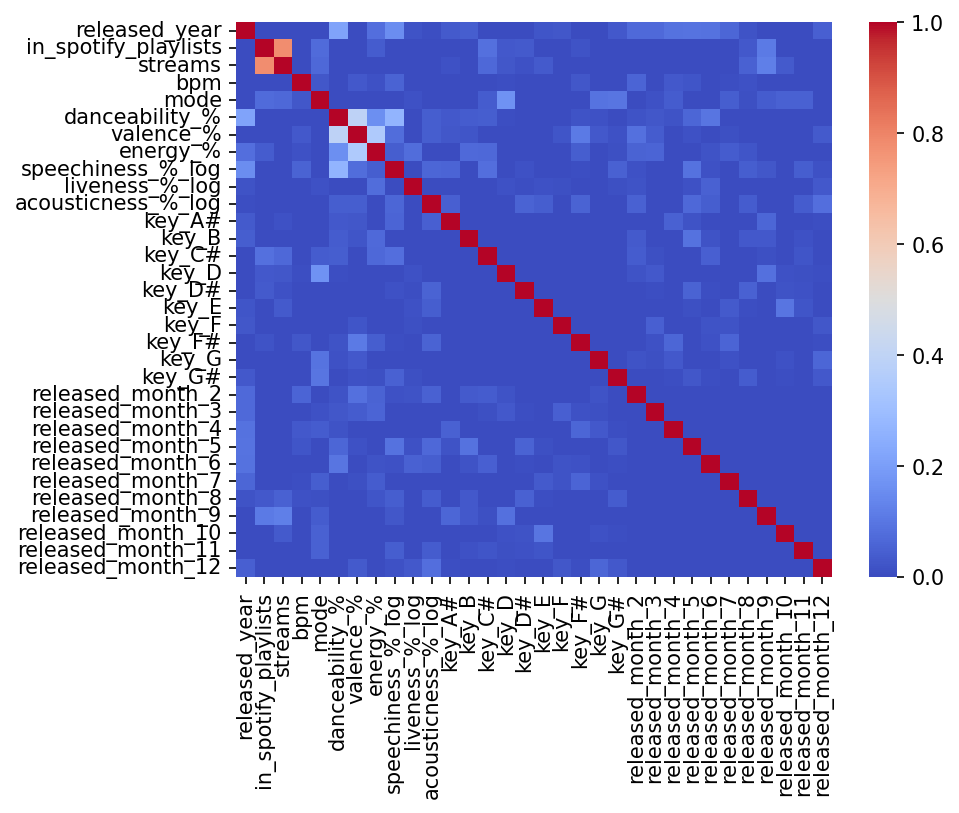

*Figure 2: Heatmap of the correlation coefficient between any two variables in the model*

The correlation coefficient between any two predictor variables no more than 0.5, which preliminarily suggests no significant multicollinearity overall. Nevertheless, this conclusion needed to be confirmed via VIF.

The absence of strong linear correlations observed between each predictor variable and `streams` (the target variable) suggests that non-linear models like Random Forest are more appropriate for this task.


*Note: Although analysis of correlation for one-hot encoded categorical variables is included for completeness, this heatmap's interpretation focuses on continuous features.* 

In [ ]:
import statsmodels.api as sm

from statsmodels.stats.outliers_influence import variance_inflation_factor


def calculate_VIF(df_encoded):
    """Calculate VIF for each predictor variable to quantify the extent of multicollinearity"""

    df_predictors_only = df_encoded.drop(['streams'], axis=1).copy()
    X = sm.add_constant(df_predictors_only)

    vif_data = pd.DataFrame()
    vif_data['feature'] = X.columns
    vif_data['VIF'] = [variance_inflation_factor(
        X.values, i) for i in range(X.shape[1])]
    print(vif_data)

All independent variables have VIF value of between 1.05 and 2.33 (all < 5). This indicates moderate correlation, which is acceptable for the initially-chosen linear regression model. Thus, no predictors were dropped since correlation coefficients remain stable.

Though Random Forest was eventually chosen as the model to use, it is robust to multicollinearity. As such, the VIF of the features remain acceptable. 

**Summary of EDA**

• Applied log-normalisation to skewed features that are based on percentages\
• No features were dropped due to multicollinearity\
• Random Forest model was preferred over linear regression due to the non-linear relationships observed between predictors and target variable\
• Performed scaling of features to ensure consistency across pipelines
